# Univariate Feature Testing

**Purpose:** Test each feature independently for predictive power.

**Key Metrics:**
- Information Coefficient (IC): Correlation with forward returns
- Hit Rate: % correct directional predictions
- Monotonicity: Stable relationship across feature quantiles
- IC Decay: How fast predictive power fades

**Acceptance Criteria:**
- |IC| > 0.05
- t-stat > 2.0
- Feature must be stationary

In [7]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.generators import (
    ma_spread, distance_from_ma, atr, rsi, 
    return_vol_ratio, close_position_in_range,
    rate_of_change, zscore_returns, breakout_indicator
)
from src.features.testing import test_feature, ic_decay_curve

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [4]:
# Load EURUSD data directly from raw CSV
data_path = '../data/raw/EURUSD_daily.csv'
eurusd = pd.read_csv(data_path)

# Parse timestamp and set as index
eurusd['timestamp'] = pd.to_datetime(eurusd['timestamp'])
eurusd = eurusd.set_index('timestamp')
eurusd = eurusd.sort_index()

# Ensure column names are lowercase
eurusd.columns = eurusd.columns.str.lower()

print(f"Data shape: {eurusd.shape}")
print(f"Date range: {eurusd.index[0]} to {eurusd.index[-1]}")
print(f"Columns: {eurusd.columns.tolist()}")

# Extract price series
prices = eurusd['close']
high = eurusd['high']
low = eurusd['low']
returns = prices.pct_change()

print(f"\nSample size: {len(prices)} bars")

NameError: name 'pd' is not defined

In [9]:
# Preview the data
print("First few rows:")
print(eurusd.head())
print("\nData info:")
print(eurusd.info())
print("\nBasic statistics:")
print(eurusd.describe())

First few rows:
                open      high       low     close  volume
timestamp                                                 
2016-02-23  1.102706  1.105199  1.099199  1.102803       0
2016-02-24  1.102499  1.104000  1.095999  1.102706       0
2016-02-25  1.101491  1.105000  1.099199  1.101394       0
2016-02-26  1.102499  1.107000  1.092600  1.102499       0
2016-02-29  1.092598  1.096200  1.086400  1.092395       0

Data info:
<class 'pandas.DataFrame'>
DatetimeIndex: 2600 entries, 2016-02-23 to 2026-02-19
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    2600 non-null   float64
 1   high    2600 non-null   float64
 2   low     2600 non-null   float64
 3   close   2600 non-null   float64
 4   volume  2600 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 121.9 KB
None

Basic statistics:
              open         high          low        close  volume
count  2600.000000  2600.000000  2600.000000 

## Generate Features

In [5]:
# Generate candidate features
features = {
    'MA_Spread_50_200': ma_spread(prices, 50, 200),
    'Distance_MA_20': distance_from_ma(prices, 20),
    'ATR_14': atr(high, low, prices, 14),
    'RSI_14': rsi(prices, 14),
    'Return_Vol_Ratio_20': return_vol_ratio(returns, 20),
    'Close_Position': close_position_in_range(high, low, prices),
    'ROC_10': rate_of_change(prices, 10),
    'ZScore_Returns_20': zscore_returns(returns, 20),
    'Breakout_20': breakout_indicator(prices, 20)
}

print(f"Generated {len(features)} features")
for name in features.keys():
    print(f"  - {name}")

NameError: name 'ma_spread' is not defined

In [2]:
# Reload the testing module to pick up bug fix
import importlib
import sys
sys.path.append('..')
import src.features.testing as testing_module
importlib.reload(testing_module)
from src.features.testing import test_feature, ic_decay_curve

print("Testing module reloaded with bug fix")

Testing module reloaded with bug fix


## Test Each Feature

In [3]:
# Test each feature for predictive power
results = {}

print("Testing Features...\n" + "="*80)

for name, feature in features.items():
    print(f"\nTesting: {name}")
    result = test_feature(feature, prices, name)
    results[name] = result
    
    print(f"  IC Mean:         {result.ic_mean:>8.4f}")
    print(f"  IC Std:          {result.ic_std:>8.4f}")
    print(f"  IC t-stat:       {result.ic_tstat:>8.2f}")
    print(f"  Hit Rate:        {result.hit_rate:>8.2%}")
    print(f"  Monotonicity:    {result.monotonicity_score:>8.2f}")
    print(f"  Stationary:      {str(result.is_stationary):>8}")
    print(f"  Decay Half-Life: {result.decay_half_life:>8} bars")
    print(f"  Significant:     {str(result.is_significant()):>8}")

print("\n" + "="*80)

Testing Features...


NameError: name 'features' is not defined

## Results Summary

In [12]:
# Create summary dataframe
summary = pd.DataFrame([
    {
        'Feature': r.feature_name,
        'IC Mean': r.ic_mean,
        'IC t-stat': r.ic_tstat,
        'Hit Rate': r.hit_rate,
        'Monotonicity': r.monotonicity_score,
        'Stationary': r.is_stationary,
        'Half-Life': r.decay_half_life,
        'Significant': r.is_significant()
    }
    for r in results.values()
])

# Sort by absolute IC
summary['abs_ic'] = summary['IC Mean'].abs()
summary = summary.sort_values('abs_ic', ascending=False).drop('abs_ic', axis=1)

print("Feature Test Summary")
print(summary.to_string(index=False))

Feature Test Summary
            Feature   IC Mean    IC t-stat  Hit Rate  Monotonicity  Stationary  Half-Life  Significant
     Close_Position -0.754292 -1501.397458  0.475183      0.000000        True          4        False
     Distance_MA_20 -0.059761   -52.842951  0.479845      0.555556        True         13        False
             ROC_10 -0.057605   -42.115071  0.481653      0.333333        True         14        False
             RSI_14 -0.047903   -31.945621  0.491106      0.444444        True         14        False
   MA_Spread_50_200 -0.045175   -42.510799  0.500833      0.555556        True          1        False
Return_Vol_Ratio_20 -0.044643   -56.122403  0.485459      0.444444        True          8        False
        Breakout_20 -0.027424   -25.596592  0.108119      0.000000        True         20        False
  ZScore_Returns_20 -0.003534    -2.149933  0.502520      0.444444        True          2        False
             ATR_14 -0.002390    -2.535623  0.491106

## Visualization: IC Comparison

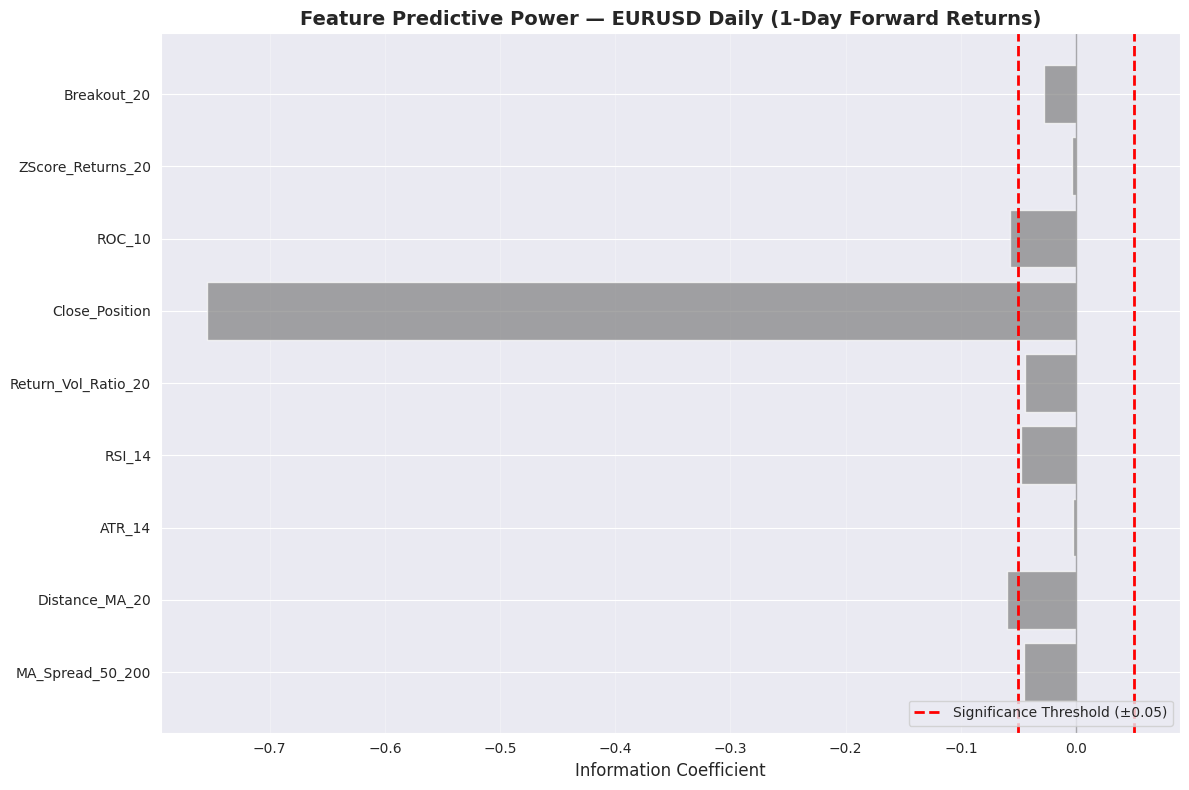

Plot saved to: ../reports/figures/ic_comparison_eurusd.png


In [13]:
# Visualize IC comparison
fig, ax = plt.subplots(figsize=(12, 8))

ic_values = [r.ic_mean for r in results.values()]
names = [r.feature_name for r in results.values()]
colors = ['green' if r.is_significant() else 'gray' for r in results.values()]

y_pos = np.arange(len(names))
ax.barh(y_pos, ic_values, color=colors, alpha=0.7)

# Add significance thresholds
ax.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Significance Threshold (±0.05)')
ax.axvline(x=-0.05, color='red', linestyle='--', linewidth=2)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.3)

ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.set_xlabel('Information Coefficient', fontsize=12)
ax.set_title('Feature Predictive Power — EURUSD Daily (1-Day Forward Returns)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/ic_comparison_eurusd.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to: ../reports/figures/ic_comparison_eurusd.png")

## IC Decay Curves

In [14]:
# Plot IC decay for significant features
significant_features = {name: feat for name, feat in features.items() 
                       if results[name].is_significant()}

if len(significant_features) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for name, feature in significant_features.items():
        decay = ic_decay_curve(feature, prices, max_horizon=20)
        ax.plot(decay.index, decay.values, marker='o', label=name, linewidth=2)
    
    ax.axhline(y=0.05, color='red', linestyle='--', alpha=0.5, label='Threshold')
    ax.axhline(y=-0.05, color='red', linestyle='--', alpha=0.5)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    ax.set_xlabel('Forward Horizon (bars)', fontsize=12)
    ax.set_ylabel('Information Coefficient', fontsize=12)
    ax.set_title('IC Decay Curves — Significant Features', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/ic_decay_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Plot saved to: ../reports/figures/ic_decay_curves.png")
else:
    print("No significant features found for decay analysis.")

No significant features found for decay analysis.


## Feature Selection Verdict

In [15]:
# Classify features
accepted = [name for name, r in results.items() if r.is_significant() and r.is_stationary]
rejected_ic = [name for name, r in results.items() if not r.is_significant()]
rejected_stationarity = [name for name, r in results.items() if r.is_significant() and not r.is_stationary]

print("FEATURE SELECTION VERDICT")
print("="*80)
print(f"\n✓ ACCEPTED ({len(accepted)}):")
for name in accepted:
    r = results[name]
    print(f"  - {name}: IC={r.ic_mean:.4f}, t-stat={r.ic_tstat:.2f}")

print(f"\n✗ REJECTED - Insufficient IC ({len(rejected_ic)}):")
for name in rejected_ic:
    r = results[name]
    print(f"  - {name}: IC={r.ic_mean:.4f}, t-stat={r.ic_tstat:.2f}")

print(f"\n✗ REJECTED - Non-Stationary ({len(rejected_stationarity)}):")
for name in rejected_stationarity:
    r = results[name]
    print(f"  - {name}: IC={r.ic_mean:.4f} (but non-stationary)")

print("\n" + "="*80)

FEATURE SELECTION VERDICT

✓ ACCEPTED (0):

✗ REJECTED - Insufficient IC (9):
  - MA_Spread_50_200: IC=-0.0452, t-stat=-42.51
  - Distance_MA_20: IC=-0.0598, t-stat=-52.84
  - ATR_14: IC=-0.0024, t-stat=-2.54
  - RSI_14: IC=-0.0479, t-stat=-31.95
  - Return_Vol_Ratio_20: IC=-0.0446, t-stat=-56.12
  - Close_Position: IC=-0.7543, t-stat=-1501.40
  - ROC_10: IC=-0.0576, t-stat=-42.12
  - ZScore_Returns_20: IC=-0.0035, t-stat=-2.15
  - Breakout_20: IC=-0.0274, t-stat=-25.60

✗ REJECTED - Non-Stationary (0):



## Save Results

In [16]:
# Save summary to CSV
summary.to_csv('../reports/feature_test_results_eurusd.csv', index=False)
print("Results saved to: ../reports/feature_test_results_eurusd.csv")

Results saved to: ../reports/feature_test_results_eurusd.csv
